# Self-Refine Self-Play Analysis

Does letting a model internally draft, critique, and refine its response — before sending it — improve its negotiation outcomes in self-play?

This notebook analyses a controlled experiment comparing **self-refine** (`SelfRefineHuggingFaceAgent` — generate → critique → refine → send) against **baseline** (`HuggingFaceAgent` — generate → send) under identical conditions.  Both players always use the same model; the only thing that varies is the strategy.

Set `MODEL_SIZE` below to switch between size tiers.  Unlike the CoT ablation, here we have multiple models per tier, so the primary comparison is **strategy per model** — any pooled number would hide heterogeneity.


In [11]:
MODEL_SIZE = "medium"   # "small" | "medium" | "iaedu"

import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)

# Reuse the helpers that back the Streamlit self-refine page.
# Walk up from cwd until we find explorer/analysis/common.py, so this works
# regardless of where the notebook is executed from.
def _find_repo_root():
    cur = Path(os.getcwd()).resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "explorer" / "analysis" / "common.py").exists():
            return parent
    raise RuntimeError("Could not locate repo root (explorer/analysis/common.py not found)")

_REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(_REPO_ROOT / "explorer"))
from analysis.common import LOGS_ROOT, clean_name, resource_value  # noqa: E402

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

SELF_REFINE_ROOT = Path(LOGS_ROOT) / "self_refine"
GAMES = {
    "trading_self_refine_v1":   "Trading",
    "ultimatum_self_refine_v1": "Ultimatum",
    "buysell_self_refine_v1":   "BuySell",
}
STRATEGIES = ["baseline", "self_refine"]   # only two present in current logs
STRATEGY_COLORS = {
    "baseline":    "#7f7f7f",   # grey — matches Streamlit page
    "self_refine": "#d62728",   # red  — matches Streamlit page
}
SIZE_LABEL = MODEL_SIZE.replace("_", " ").title()

print(f"Model size : {SIZE_LABEL}")
print(f"Logs root  : {SELF_REFINE_ROOT}")

Model size : Medium
Logs root  : /home/adriano/Desktop/MultiAgent-Negotiation/.logs/self_refine


## Experimental Design

| Dimension | Value |
|--|-|
| **Strategies** | `baseline` (one-shot) vs `self_refine` (draft → feedback → refine → send) |
| **Games** | Trading, Ultimatum, BuySell |
| **Play mode** | Self-play (same model on both sides, same strategy on both sides) |
| **Models (medium)** | gemma-3-27b-it, mistral-small-3.2-24b, qwen3.5-27b |
| **Models (small)** | gemma-3-12b-it, ministral-3-14b-instruct, qwen3-14b |
| **Models (iaedu)** | gpt-4o-iaedu |
| **Runs per cell** | ≈ 10 (small) · 30 (medium, uneven) · ≤ 3 (iaedu) |

Coverage is uneven — some cells have fewer runs than others (especially `self_refine` in Ultimatum medium, and everything in `iaedu`).  Tests on cells with n < 3 per side are skipped with an `n too small` note.


In [12]:
# ---- Run loader (ported from explorer/pages/6_self_refine_analysis.py) ----
def parse_run_path(game_state_path: Path) -> dict:
    parts = game_state_path.parts
    idx = parts.index("self_refine")
    experiment = parts[idx + 1]
    size = parts[idx + 2]
    strategy = None
    for piece in reversed(parts[idx + 3 : -1]):
        for s in STRATEGIES:
            if piece.endswith("_" + s) or piece == s:
                strategy = s
                break
        if strategy:
            break
    run_id = parts[-2]
    pair_raw = parts[idx + 3]
    pair = pair_raw
    for s in STRATEGIES:
        if pair.endswith("_" + s):
            pair = pair[: -(len(s) + 1)]
    return dict(experiment=experiment, size=size, pair=pair, strategy=strategy, run_id=run_id)


def extract_outcome(game_prefix: str, data: dict) -> dict:
    gs = data["game_state"]
    last = gs[-1]
    completed = last.get("current_iteration") == "END"
    turn_states = [s for s in gs if s.get("current_iteration") not in ("START", "END")]
    out = dict(
        game=game_prefix,
        completed=completed,
        num_turns=len(turn_states),
        total_parse_retries=data.get("total_parse_retries", 0),
        model_1=data["players"][0].get("model_id", data["players"][0].get("model")),
        model_2=data["players"][1].get("model_id", data["players"][1].get("model")),
    )
    if not completed:
        return out
    summary = last.get("summary", {})
    out["final_response"] = summary.get("final_response")
    out["deal"] = summary.get("final_response") == "ACCEPT"
    if game_prefix == "BuySell":
        oc = summary.get("player_outcome", [None, None])
        out["payoff_1"] = oc[0]
        out["payoff_2"] = oc[1]
    else:
        init = summary.get("initial_resources")
        final = summary.get("final_resources")
        if init and final:
            d1 = resource_value(final[0]) - resource_value(init[0])
            d2 = resource_value(final[1]) - resource_value(init[1])
            if game_prefix == "Ultimatum":
                # Convert delta → dollars each player walks away with.
                # Proposer starts at $100, loses what's transferred. A REJECT leaves
                # both deltas at 0; treat that as "nobody got anything" (standard UG convention).
                d1 = d1 + 100
                if d1 == 100:
                    d1 = 0
            out["payoff_1"] = d1
            out["payoff_2"] = d2
    return out


def load_all_runs():
    rows = []
    for exp_dir, game_name in GAMES.items():
        root = SELF_REFINE_ROOT / exp_dir
        if not root.exists():
            continue
        for gs_path in root.rglob("game_state.json"):
            try:
                meta = parse_run_path(gs_path)
                if meta["strategy"] is None:
                    continue
                with open(gs_path) as f:
                    data = json.load(f)
                out = extract_outcome(game_name, data)
                rows.append({**meta, **out, "run_dir": str(gs_path.parent)})
            except Exception:
                continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["model_short"] = df["model_1"].map(clean_name)
    df["surplus"] = df.get("payoff_1", pd.Series(dtype=float)).fillna(0) \
                  + df.get("payoff_2", pd.Series(dtype=float)).fillna(0)
    return df


# ---- Stats helpers (same shape as cot_ablation_analysis.ipynb) ----
MIN_N_FOR_TEST = 3   # skip Mann-Whitney / Fisher when either side has fewer samples

def mann_whitney(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < MIN_N_FOR_TEST or len(b) < MIN_N_FOR_TEST:
        return np.nan, np.nan
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return u, p


def cohens_d(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    pooled = np.sqrt(((n1 - 1) * a.std(ddof=1)**2 + (n2 - 1) * b.std(ddof=1)**2) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


def fisher_exact(a_succ, a_n, b_succ, b_n):
    if min(a_n, b_n) < MIN_N_FOR_TEST:
        return np.nan
    table = [[a_succ, a_n - a_succ], [b_succ, b_n - b_succ]]
    try:
        _, p = stats.fisher_exact(table)
        return p
    except Exception:
        return np.nan


def format_p(p):
    if np.isnan(p):
        return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s." 

In [13]:
df_all = load_all_runs()
df = df_all[df_all["size"] == MODEL_SIZE].copy() if not df_all.empty else df_all

if df.empty:
    raise FileNotFoundError(
        f"No self-refine runs found for MODEL_SIZE={MODEL_SIZE!r}. "
        f"Check {SELF_REFINE_ROOT}."
    )

print(f"{'Game':<12} {'Model':<36} {'Strategy':<12} {'Total':>6} {'Completed':>10}")
print("-" * 80)
for game in sorted(df["game"].unique()):
    for model in sorted(df[df["game"] == game]["model_short"].unique()):
        for strat in STRATEGIES:
            sub = df[(df["game"] == game) & (df["model_short"] == model) & (df["strategy"] == strat)]
            if sub.empty:
                continue
            total = len(sub)
            done = int(sub["completed"].sum())
            print(f"{game:<12} {model:<36} {strat:<12} {total:>6} {done:>10}")
print(f"\nTotal rows for {SIZE_LABEL}: {len(df)}")

Game         Model                                Strategy      Total  Completed
--------------------------------------------------------------------------------
BuySell      Mistral-Small-3.2-24B-2506           baseline         30         19
BuySell      Mistral-Small-3.2-24B-2506           self_refine      14          9
BuySell      gemma-3-27b-it                       baseline         31         30
BuySell      gemma-3-27b-it                       self_refine      30         30
Trading      Mistral-Small-3.2-24B-2506           baseline         30         17
Trading      Mistral-Small-3.2-24B-2506           self_refine      30         16
Trading      Qwen3.5-27B                          baseline         30         12
Trading      Qwen3.5-27B                          self_refine       9          7
Trading      gemma-3-27b-it                       baseline         31         28
Trading      gemma-3-27b-it                       self_refine      30         22
Ultimatum    gemma-3-27b-it 

## 1. Game Completion Rates

A game is **completed** if it reached the `END` iteration; otherwise the run hit an `ERROR` or timed out with an unparseable message.  Self-refine issues *more* LLM calls per turn (draft + feedback + refine), so it has more opportunities for a malformed message to abort the run — we want to know whether that cost actually materialises.


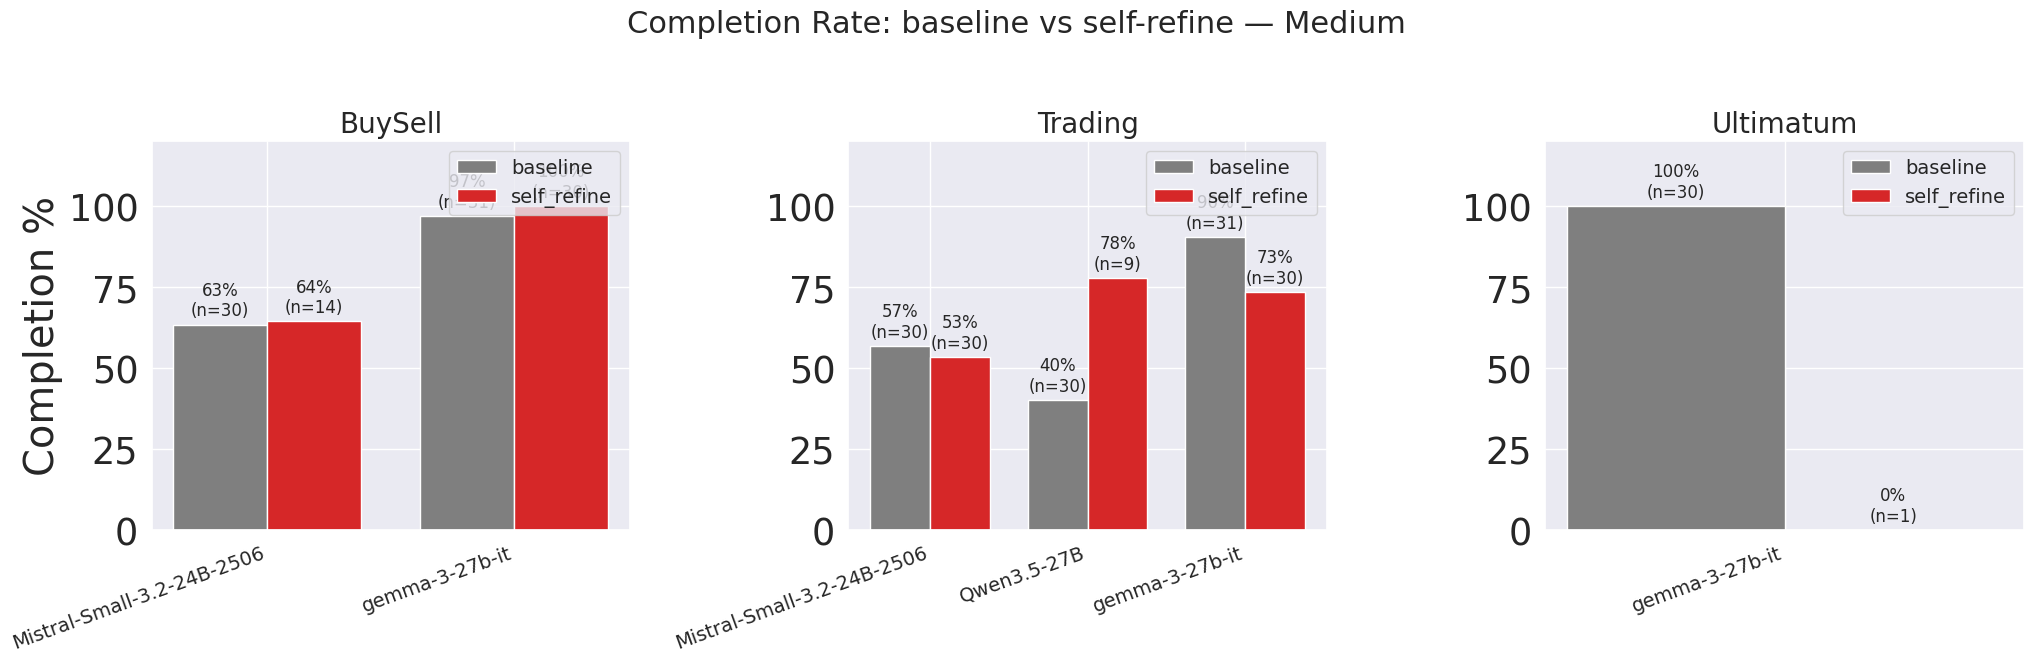


Fisher's exact test — baseline vs self_refine completion:
  BuySell     Mistral-Small-3.2-24B-2506           p=1.0000 n.s.
  BuySell     gemma-3-27b-it                       p=1.0000 n.s.
  Trading     Mistral-Small-3.2-24B-2506           p=1.0000 n.s.
  Trading     Qwen3.5-27B                          p=0.0648 n.s.
  Trading     gemma-3-27b-it                       p=0.1056 n.s.
  Ultimatum   gemma-3-27b-it                       p=nan n/a


In [14]:
agg = df.groupby(["game", "model_short", "strategy"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = sorted(agg["game"].unique())
fig, axes = plt.subplots(1, len(games), figsize=(7 * len(games), 7), squeeze=False)

for ax, game in zip(axes[0], games):
    sub = agg[agg["game"] == game]
    models = sorted(sub["model_short"].unique())
    x = np.arange(len(models))
    width = 0.38
    for i, strat in enumerate(STRATEGIES):
        pct = [sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["pct"].sum()
               for m in models]
        totals = [int(sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["total"].sum())
                  for m in models]
        bars = ax.bar(x + (i - 0.5) * width, pct, width,
                      label=strat, color=STRATEGY_COLORS[strat])
        for bar, v, n in zip(bars, pct, totals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                    f"{v:.0f}%\n(n={n})", ha="center", va="bottom", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14, rotation=20, ha="right")
    ax.set_ylim(0, 120)
    ax.set_ylabel("Completion %" if ax is axes[0][0] else "")
    ax.set_title(game, fontsize=20)
    ax.legend(fontsize=14, loc="upper right")

fig.suptitle(f"Completion Rate: baseline vs self-refine — {SIZE_LABEL}", fontsize=22)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_completion_rates.pdf", bbox_inches="tight")
plt.show()

# Fisher's exact per (game × model)
print("\nFisher's exact test — baseline vs self_refine completion:")
for game in games:
    for m in sorted(agg[agg["game"] == game]["model_short"].unique()):
        b = agg[(agg["game"] == game) & (agg["model_short"] == m) & (agg["strategy"] == "baseline")]
        s = agg[(agg["game"] == game) & (agg["model_short"] == m) & (agg["strategy"] == "self_refine")]
        if b.empty or s.empty:
            continue
        p = fisher_exact(int(b["completed"].iloc[0]), int(b["total"].iloc[0]),
                         int(s["completed"].iloc[0]), int(s["total"].iloc[0]))
        print(f"  {game:<11} {m:<36} p={p:.4f} {format_p(p) if not np.isnan(p) else 'n/a'}")

## 2. Negotiation Outcomes

Among games that completed, does self-refine change what the agents walk away with?

- **Trading** — resource delta relative to each player's starting inventory (zero-sum under 1:1 valuation).
- **Ultimatum** — dollars each player ends up with: proposer keeps $100 − transferred, responder receives the transfer.  Rejected deals give both $0.
- **BuySell** — seller / buyer profit (`summary.player_outcome`).  Positive = profit, 0 = no-deal or break-even.


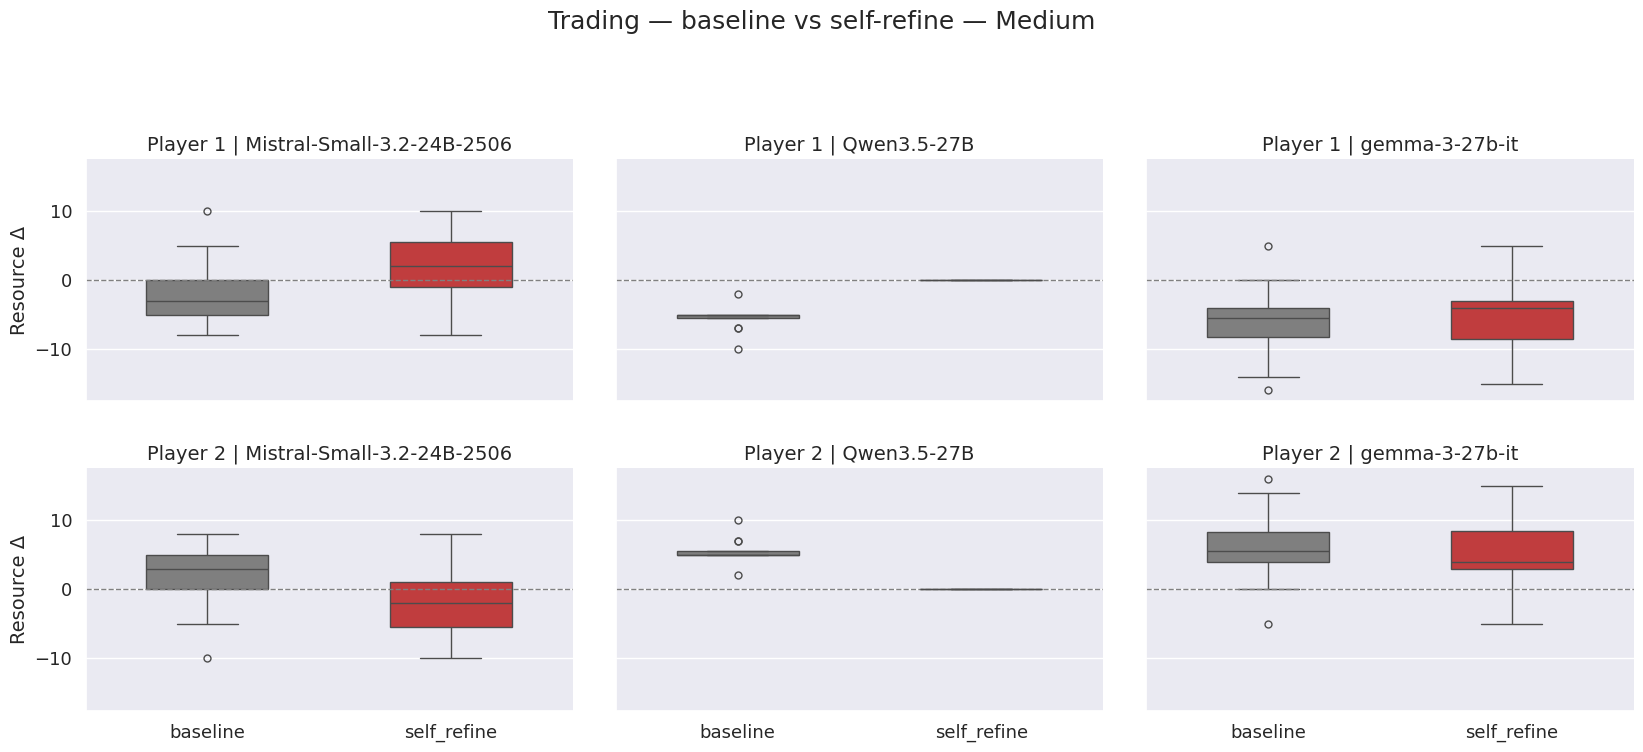


Trading — Mann-Whitney on Player 1 payoff, per model:
  Mistral-Small-3.2-24B-2506            baseline μ=-2.12 (n=17)  self_refine μ=+1.88 (n=16)  U=76  p=0.0308 *  d=-0.79
  Qwen3.5-27B                           baseline μ=-5.50 (n=12)  self_refine μ=+0.00 (n=7)  U=0  p=0.0002 ***  d=-3.63
  gemma-3-27b-it                        baseline μ=-6.04 (n=28)  self_refine μ=-5.23 (n=22)  U=253  p=0.2841 n.s.  d=-0.18


In [15]:
tdf = df[(df["game"] == "Trading") & df["completed"] & df["payoff_1"].notna()].copy()

if tdf.empty:
    print("No completed Trading runs for this size.")
else:
    plot_df = pd.melt(
        tdf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Player 1", "payoff_2": "Player 2"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="payoff", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", ls="--", lw=1)
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Resource Δ", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"Trading — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_trading.pdf", bbox_inches="tight")
    plt.show()

    # Per-model Mann-Whitney + Cohen's d (on P1 — by symmetry P2 is the inverse)
    print("\nTrading — Mann-Whitney on Player 1 payoff, per model:")
    for m in sorted(tdf["model_short"].unique()):
        b = tdf[(tdf["model_short"] == m) & (tdf["strategy"] == "baseline")]["payoff_1"]
        s = tdf[(tdf["model_short"] == m) & (tdf["strategy"] == "self_refine")]["payoff_1"]
        u, p = mann_whitney(b, s)
        d = cohens_d(b, s)
        if np.isnan(p):
            print(f"  {m:<36}  n too small (baseline={len(b)}, self_refine={len(s)})")
        else:
            print(f"  {m:<36}  baseline μ={b.mean():+.2f} (n={len(b)})  "
                  f"self_refine μ={s.mean():+.2f} (n={len(s)})  "
                  f"U={u:.0f}  p={p:.4f} {format_p(p)}  d={d:+.2f}")

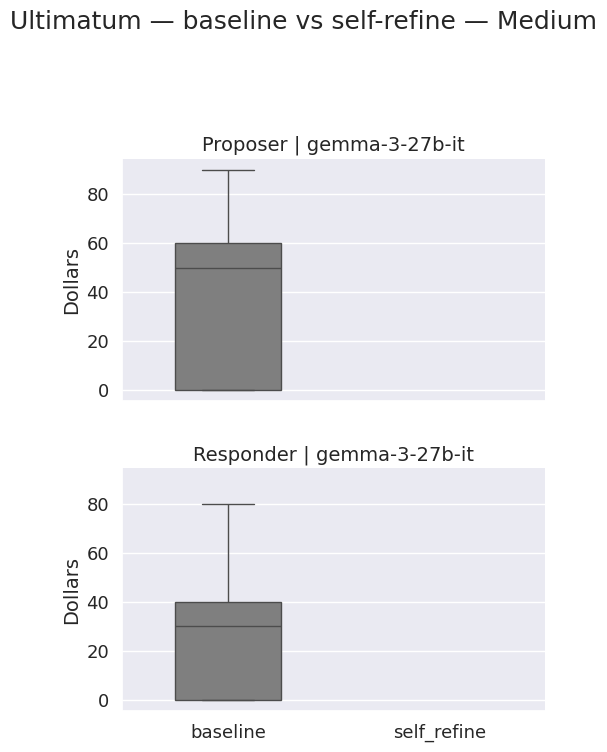


Ultimatum — ACCEPT rate:
  gemma-3-27b-it                        baseline      accept= 63.3%  (n=30)

Ultimatum — Mann-Whitney on Proposer payoff, per model:
  gemma-3-27b-it                        n too small (baseline=30, self_refine=0)


In [16]:
udf = df[(df["game"] == "Ultimatum") & df["completed"] & df["payoff_1"].notna()].copy()

if udf.empty:
    print("No completed Ultimatum runs for this size.")
else:
    plot_df = pd.melt(
        udf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Proposer", "payoff_2": "Responder"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="payoff", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Dollars", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"Ultimatum — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_ultimatum.pdf", bbox_inches="tight")
    plt.show()

    # Deal (ACCEPT) rate per model × strategy
    deal = (udf.groupby(["model_short", "strategy"])["deal"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "accept_rate", "count": "n"})
                .reset_index())
    print("\nUltimatum — ACCEPT rate:")
    for _, r in deal.iterrows():
        print(f"  {r['model_short']:<36}  {r['strategy']:<12}  "
              f"accept={r['accept_rate']*100:5.1f}%  (n={int(r['n'])})")

    print("\nUltimatum — Mann-Whitney on Proposer payoff, per model:")
    for m in sorted(udf["model_short"].unique()):
        b = udf[(udf["model_short"] == m) & (udf["strategy"] == "baseline")]["payoff_1"]
        s = udf[(udf["model_short"] == m) & (udf["strategy"] == "self_refine")]["payoff_1"]
        u, p = mann_whitney(b, s)
        d = cohens_d(b, s)
        if np.isnan(p):
            print(f"  {m:<36}  n too small (baseline={len(b)}, self_refine={len(s)})")
        else:
            print(f"  {m:<36}  baseline μ=${b.mean():.1f} (n={len(b)})  "
                  f"self_refine μ=${s.mean():.1f} (n={len(s)})  "
                  f"U={u:.0f}  p={p:.4f} {format_p(p)}  d={d:+.2f}")

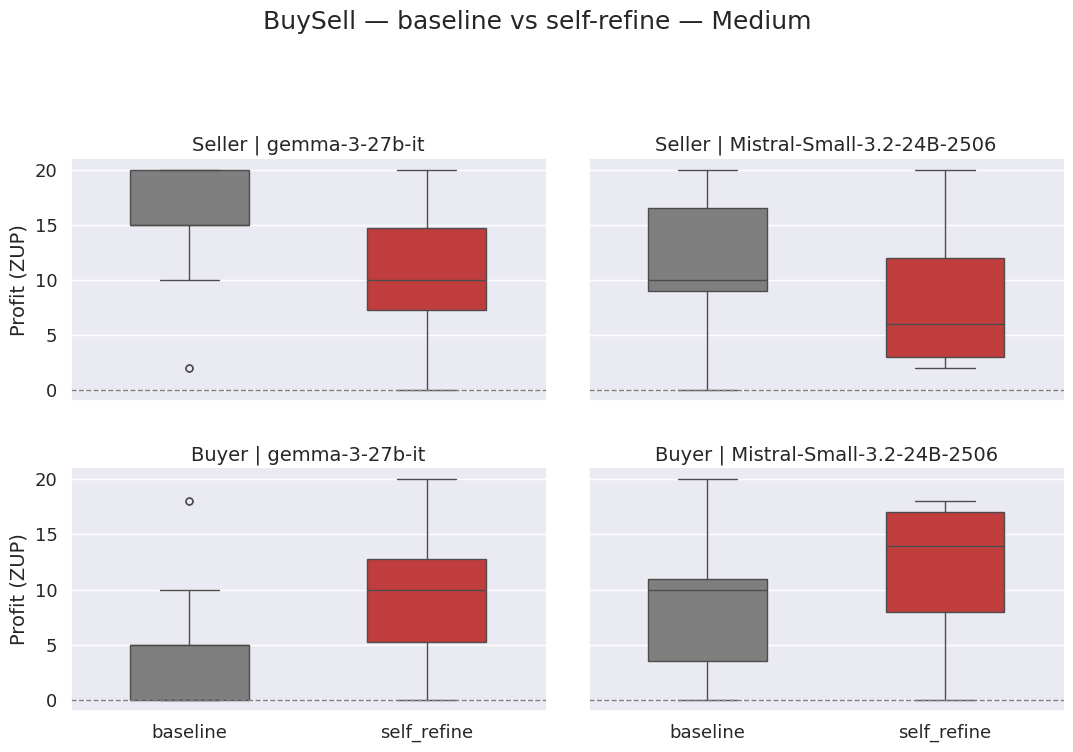


BuySell — Mann-Whitney on seller profit, per model (joint surplus is fixed at 20 per completed run; test compares the split):
  Mistral-Small-3.2-24B-2506            baseline μ=11.37 (n=19)  self_refine μ=8.56 (n=9)  U=104  p=0.3571 n.s.  d=+0.42
  gemma-3-27b-it                        baseline μ=15.30 (n=30)  self_refine μ=10.70 (n=30)  U=659  p=0.0016 **  d=+0.81


In [17]:
bdf = df[(df["game"] == "BuySell") & df["completed"] & df["payoff_1"].notna()].copy()

if bdf.empty:
    print("No completed BuySell runs for this size.")
else:
    plot_df = pd.melt(
        bdf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="profit",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Seller", "payoff_2": "Buyer"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="profit", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", ls="--", lw=1)
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Profit (ZUP)", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"BuySell — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_buysell.pdf", bbox_inches="tight")
    plt.show()

    # Every completed BuySell run has joint surplus = 20 (fixed by game setup),
    # so the interesting quantity is the split — how much the seller captured.
    print("\nBuySell — Mann-Whitney on seller profit, per model "
          "(joint surplus is fixed at 20 per completed run; test compares the split):")
    for m in sorted(bdf["model_short"].unique()):
        b = bdf[(bdf["model_short"] == m) & (bdf["strategy"] == "baseline")]["payoff_1"]
        s = bdf[(bdf["model_short"] == m) & (bdf["strategy"] == "self_refine")]["payoff_1"]
        u, p = mann_whitney(b, s)
        d = cohens_d(b, s)
        if np.isnan(p):
            print(f"  {m:<36}  n too small (baseline={len(b)}, self_refine={len(s)})")
        else:
            print(f"  {m:<36}  baseline μ={b.mean():.2f} (n={len(b)})  "
                  f"self_refine μ={s.mean():.2f} (n={len(s)})  "
                  f"U={u:.0f}  p={p:.4f} {format_p(p)}  d={d:+.2f}")

## 3. Negotiation Dynamics

Self-refine agents think more per turn — does that translate into fewer *turns* (they converge faster because each message is higher-quality), more turns (they counter-propose more confidently), or no change?


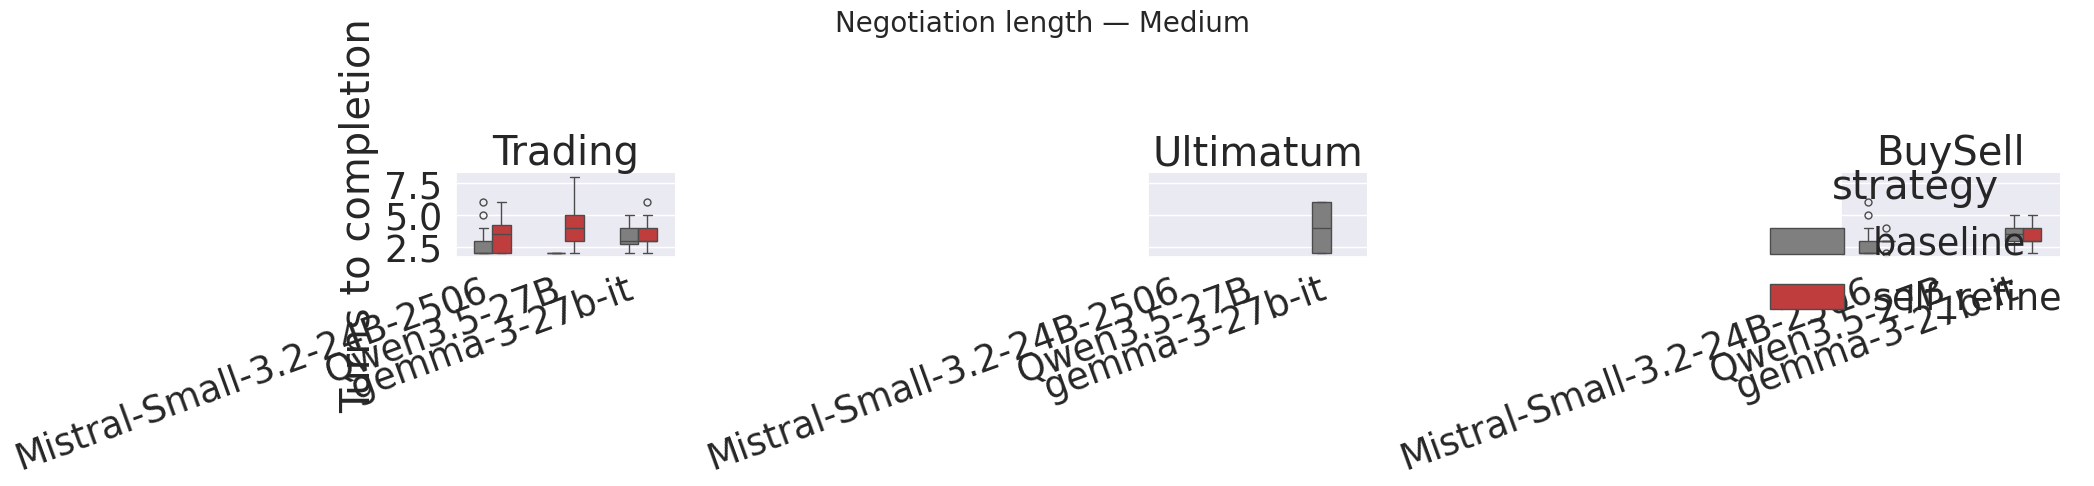


Turns — Mann-Whitney per (game × model):
  BuySell     Mistral-Small-3.2-24B-2506            baseline μ=2.8  self_refine μ=3.0  p=0.2328 n.s.  d=-0.16
  BuySell     gemma-3-27b-it                        baseline μ=3.6  self_refine μ=3.4  p=0.3584 n.s.  d=+0.19
  Trading     Mistral-Small-3.2-24B-2506            baseline μ=2.8  self_refine μ=3.4  p=0.1717 n.s.  d=-0.47
  Trading     Qwen3.5-27B                           baseline μ=2.0  self_refine μ=4.3  p=0.0003 ***  d=-1.87
  Trading     gemma-3-27b-it                        baseline μ=3.4  self_refine μ=3.4  p=0.9756 n.s.  d=-0.05
  Ultimatum   gemma-3-27b-it                        n too small


In [18]:
turns_df = df[df["completed"]].copy()

if turns_df.empty:
    print("No completed runs for this size.")
else:
    g = sns.catplot(
        data=turns_df, x="model_short", y="num_turns",
        hue="strategy", hue_order=STRATEGIES, palette=STRATEGY_COLORS,
        col="game", kind="box", height=5, aspect=1.2, width=0.5,
    )
    g.set_axis_labels("", "Turns to completion")
    g.set_titles("{col_name}")
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=20)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")
    g.fig.suptitle(f"Negotiation length — {SIZE_LABEL}", fontsize=20, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_turns.pdf", bbox_inches="tight")
    plt.show()

    print("\nTurns — Mann-Whitney per (game × model):")
    for game in sorted(turns_df["game"].unique()):
        for m in sorted(turns_df[turns_df["game"] == game]["model_short"].unique()):
            b = turns_df[(turns_df["game"] == game) & (turns_df["model_short"] == m)
                         & (turns_df["strategy"] == "baseline")]["num_turns"]
            s = turns_df[(turns_df["game"] == game) & (turns_df["model_short"] == m)
                         & (turns_df["strategy"] == "self_refine")]["num_turns"]
            u, p = mann_whitney(b, s)
            d = cohens_d(b, s)
            if np.isnan(p):
                print(f"  {game:<11} {m:<36}  n too small")
            else:
                print(f"  {game:<11} {m:<36}  "
                      f"baseline μ={b.mean():.1f}  self_refine μ={s.mean():.1f}  "
                      f"p={p:.4f} {format_p(p)}  d={d:+.2f}")